In [2]:
#%pip install openpyxl wordcloud flair hdbscan==0.8.40 bertopic spacy numpy==1.26.4

In [1]:
import pandas as pd
import os
import platform
from wordcloud import WordCloud

In [2]:
platform.__version__

'1.0.8'

In [3]:
def is_running_on_azure():
    return "AML_CloudName" in os.environ

In [6]:
if is_running_on_azure() is True:
    from azure.ai.ml import MLClient
    from azure.identity import DefaultAzureCredential

    ml_client = MLClient.from_config(credential=DefaultAzureCredential())
    data_asset = ml_client.data.get("fnopi", version="1")

    df_prestazioni_inf_corretto = pd.read_csv(data_asset.path+"df_prestazioni_inf_corretto.csv", sep='\t',encoding='latin-1')

else:
    df_prestazioni_inf_corretto = pd.read_csv("dataset/df_prestazioni_inf_corretto.csv", sep='\t',encoding='latin-1')


Found the config file in: /config.json
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


In [7]:
df_prestazioni_inf_corretto.columns

Index(['index', 'macroprestazione', 'testo', 'testo_pulito', 'testo_corretto',
       'cod_valoremedio_liquidazione', 'descr_cod_valoremedio_liquidazione'],
      dtype='object')

In [8]:
df_prestazioni_inf_corretto.head()

,index,macroprestazione,testo,testo_pulito,testo_corretto,cod_valoremedio_liquidazione,descr_cod_valoremedio_liquidazione
0,0,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi ematici,prelievi ematici,prelievo ematico,033T,Prelievo capillare e venoso del sangue o racco...
1,1,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi venosi,prelievi venosi,prelievo venoso,033T,Prelievo capillare e venoso del sangue o racco...
2,2,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi,prelievi,prelievo,033T,Prelievo capillare e venoso del sangue o racco...
3,3,Medicazioni Avanzate,Medicazioni varie,medicazioni varie,medicazione varie,031T,Medicazione semplice
4,4,procedure clinico assistenziali,Clistere /svuotamento manuale,clistere svuotamento manuale,clistere svuotamento manuale,080T,Preparazione ed effettuazione di clistere


In [9]:
print("Numero di prestazioni sanitarie: " + str(len(df_prestazioni_inf_corretto)))

Numero di prestazioni sanitarie: 22614


### Wordcloud dei testi

In [25]:
len(df_prestazioni_inf_corretto[df_prestazioni_inf_corretto.isna().any(axis=1)])

33

In [ ]:
df_prestazioni_inf_corretto.dropna(inplace=True)
len(df_prestazioni_inf_corretto)

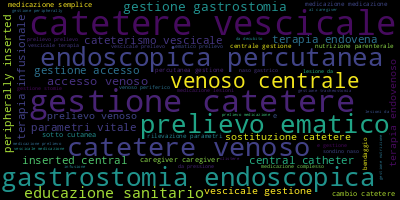

In [23]:
full_text = ','.join(list(df_prestazioni_inf_corretto["testo_corretto"].dropna().astype(str).values))
wordcloud = WordCloud(background_color="black",
                        max_words=100,
                        contour_width=2,
                        contour_color='yellow')

wordcloud.generate(full_text)
wordcloud.to_image()

### Exploratory Data Analysis

In [34]:
df_prestazioni_inf_corretto.groupby('testo_corretto').count()[['macroprestazione']].rename(columns={'macroprestazione': 'count'}).sort_values(by='count', ascending=False).to_csv("csv/N_prestazioni_by_note_infermieristiche_testo_corretto.csv", sep=';')